In [203]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


[def]: attachment:image.png

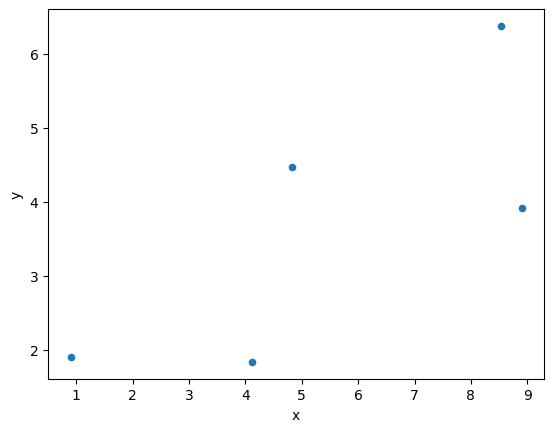

In [204]:
df=pd.DataFrame({'x': [0.9, 4.11, 4.82, 8.53, 8.9], 
                 'y': [1.91, 1.84, 4.47, 6.38, 3.92]})
df.plot(x='x', y='y', kind='scatter')
plt.show()

In [205]:
df

,x,y
0,0.90,1.91
1,4.11,1.84
2,4.82,4.47
3,8.53,6.38
4,8.90,3.92


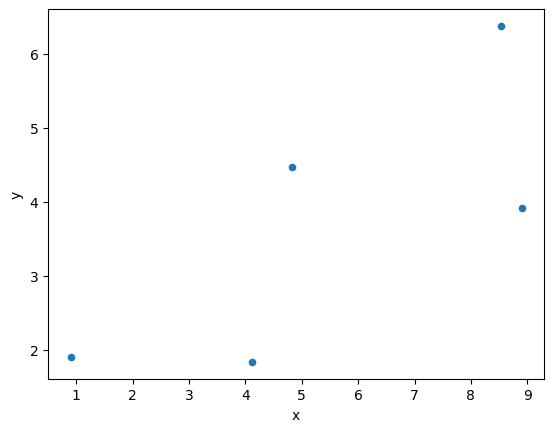

In [206]:
df = pd.DataFrame({'x': [0.9, 4.11, 4.82, 8.53, 8.9], 
                  'y': [1.91, 1.84, 4.47, 6.38, 3.92]})

df.plot(x="x", y="y", kind="scatter")
plt.show()

In [207]:
# инициализация весов происходит в автоматическом режиме, рандомно. Если алгоритм попал по весам, то инициализация займет меньше времени.
w, b = 1, 1

In [208]:
df['y_pred'] = df['x'] * w + b

In [209]:
df

,x,y,y_pred
0,0.90,1.91,1.90
1,4.11,1.84,5.11
2,4.82,4.47,5.82
3,8.53,6.38,9.53
4,8.90,3.92,9.90


In [210]:
plt.scatter?

# ? - это сигнатура функции

Signature:
plt.scatter(
    x: 'float | ArrayLike',
    y: 'float | ArrayLike',
    s: 'float | ArrayLike | None' = None,
    c: 'ArrayLike | Sequence[ColorType] | ColorType | None' = None,
    marker: 'MarkerType | None' = None,
    cmap: 'str | Colormap | None' = None,
    norm: 'str | Normalize | None' = None,
    vmin: 'float | None' = None,
    vmax: 'float | None' = None,
    alpha: 'float | None' = None,
    linewidths: 'float | Sequence[float] | None' = None,
    *,
    edgecolors: "Literal['face', 'none'] | ColorType | Sequence[ColorType] | None" = None,
    plotnonfinite: 'bool' = False,
    data=None,
    **kwargs,
) -> 'PathCollection'
Docstring:
A scatter plot of *y* vs. *x* with varying marker size and/or color.

Parameters
----------
x, y : float or array-like, shape (n, )
    The data positions.

s : float or array-like, shape (n, ), optional
    The marker size in points**2 (typographic points are 1/72 in.).
    Default is ``rcParams['lines.markersize'] ** 2``.

    Th

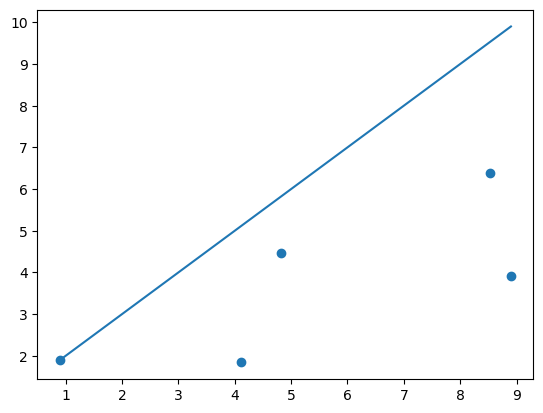

In [211]:
# x: 'float | ArrayLike',
# y: 'float | ArrayLike',
plt.scatter(x=df["x"], y=df["y"])
plt.plot(df["x"], df["y_pred"])
plt.show()

In [212]:
plt.plot?

Signature:
plt.plot(
    *args: 'float | ArrayLike | str',
    scalex: 'bool' = True,
    scaley: 'bool' = True,
    data=None,
    **kwargs,
) -> 'list[Line2D]'
Docstring:
Plot y versus x as lines and/or markers.

Call signatures::

    plot([x], y, [fmt], *, data=None, **kwargs)
    plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

The coordinates of the points or line nodes are given by *x*, *y*.

The optional parameter *fmt* is a convenient way for defining basic
formatting like color, marker and linestyle. It's a shortcut string
notation described in the *Notes* section below.

>>> plot(x, y)        # plot x and y using default line style and color
>>> plot(x, y, 'bo')  # plot x and y using blue circle markers
>>> plot(y)           # plot y using x as index array 0..N-1
>>> plot(y, 'r+')     # ditto, but with red plusses

You can use `.Line2D` properties as keyword arguments for more
control on the appearance. Line properties and *fmt* can be mixed.
The following two calls yie

In [213]:
df["err_abs"] = np.abs(df["y"] - df["y_pred"])
df["err_abs"]


0    0.01
1    3.27
2    1.35
3    3.15
4    5.98
Name: err_abs, dtype: float64

In [214]:
df["err_abs"].mean()

2.7520000000000002

In [215]:
# что сделать если ошибка будет 0 по какому нибудь наблюдению?
# делить на 0 нельзя

# e1/|e1|
# e1/|0| запрещено делить на 0
# e1  = y_true - y_pred
# e1  = 5 - 5


In [216]:
np.sign(-9999)

-1

In [217]:
np.sign(9999)


1

In [218]:
np.sign(0)


0

In [219]:
# df['w_change'] = df['x'] * (df['y'] - df['y_pred'])/np.abs(df['y'] - df['y_pred']) деление на ноль
# Доопределение функции - это второй способ решения проблемы с негладкой оптимизацией

In [220]:
ei = df['y'] - df['y_pred']
df["w_change"] = np.where(
    df["y"] != df["y_pred"],
    df['x'] * (ei)/np.abs(ei),
    0,
)

In [221]:
df

,x,y,y_pred,err_abs,w_change
0,0.90,1.91,1.90,0.01,0.90
1,4.11,1.84,5.11,3.27,-4.11
2,4.82,4.47,5.82,1.35,-4.82
3,8.53,6.38,9.53,3.15,-8.53
4,8.90,3.92,9.90,5.98,-8.90


In [222]:
df["w_change"] = df["x"] * np.sign(ei)
df

,x,y,y_pred,err_abs,w_change
0,0.90,1.91,1.90,0.01,0.90
1,4.11,1.84,5.11,3.27,-4.11
2,4.82,4.47,5.82,1.35,-4.82
3,8.53,6.38,9.53,3.15,-8.53
4,8.90,3.92,9.90,5.98,-8.90


In [223]:
df["w_change"].mean()

-5.0920000000000005

In [224]:
df["b_change"] = np.sign(ei)

In [225]:
df["b_change"].mean()

-0.6

In [226]:
w, b

(1, 1)

In [227]:
nu = 1 # learning rate

In [228]:
w = w + nu * df["w_change"].mean()
b = b + nu * df["b_change"].mean()
w, b

(-4.0920000000000005, 0.4)

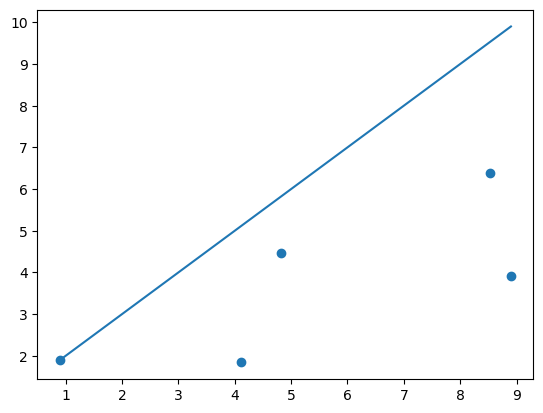

In [229]:
x=plt.scatter(df["x"], y=df["y"])
plt.plot(df["x"], df["y_pred"])
plt.show()

In [230]:
w, b = 1, 1
nu = 0.05
n_iters = 100  # количество эпох (итераций)
df = df[["x", "y"]].copy()
df["y_pred"] = w * df['x'] + b
for i in range(n_iters):
    # 1. counting error
    df["err"] = df["y"] - df["y_pred"] 
    # 2. Субградиент для l1 (МАЕ, Манхэттенское расстояние)
    # Субградиент — это вектор, множество таких векторов — это субдифференциал
    # В данном случае субградиент сходится медленнее и дрожит около оптимума, особенно если шаг обучения слишком большой
    # Здесь используется полный батч, полный градиент. Time complexity при больших наблюдениях у нас отображается линейно — это значит если матрица будет 1000 признаков, уже будет плохо. Сходится плавно.
    # Задача оптимизации подразумевает sgd — стохастический градиентный спуск — он сходится менее плавно, но он не требует больших вычислительных ресурсов. Берется группа точек из всего датасета - это и есть понятие мини-батч. Сходится хуже, больше отклоняется от теоретической нормали.
    df["w_change"] = df["x"] * np.sign(df["err"]) * (-1)
    df["b_change"] = np.sign(df["err"]) * (-1)
    # 3. Обновляем веса
    w = w - nu * df["w_change"].mean()
    b = b - nu * df["b_change"].mean()

    # Критерий останова — разница весов текущего и следующего должна быть меньше епсилон.
    # В данном случае считается полный батч (то етсь мы берем все иксы, все данные).
       
    # 4 
    df["y_pred"] = w * df["x"] + b 
    df["err_abs"] = np.abs(df["y"] - df["y_pred"])

    # 5 Выводим текущую итерацию
    print(f"iteration {i+1:3d}, MAE: {df['err_abs'].mean():.5f}")

print(f"w = {w:4f}, b = {b:5f}")


iteration   1, MAE: 1.43758
iteration   2, MAE: 1.09028
iteration   3, MAE: 1.08521
iteration   4, MAE: 1.08013
iteration   5, MAE: 1.07506
iteration   6, MAE: 1.06998
iteration   7, MAE: 1.06491
iteration   8, MAE: 1.05983
iteration   9, MAE: 1.05476
iteration  10, MAE: 1.04968
iteration  11, MAE: 1.04460
iteration  12, MAE: 1.03953
iteration  13, MAE: 1.04246
iteration  14, MAE: 1.07569
iteration  15, MAE: 1.07061
iteration  16, MAE: 1.06554
iteration  17, MAE: 1.06046
iteration  18, MAE: 1.05539
iteration  19, MAE: 1.05031
iteration  20, MAE: 1.04524
iteration  21, MAE: 1.04016
iteration  22, MAE: 1.03509
iteration  23, MAE: 1.03001
iteration  24, MAE: 1.02494
iteration  25, MAE: 1.01986
iteration  26, MAE: 1.03472
iteration  27, MAE: 1.05602
iteration  28, MAE: 1.05094
iteration  29, MAE: 1.04587
iteration  30, MAE: 1.04079
iteration  31, MAE: 1.03572
iteration  32, MAE: 1.03064
iteration  33, MAE: 1.02557
iteration  34, MAE: 1.02049
iteration  35, MAE: 1.01542
iteration  36, MAE: 

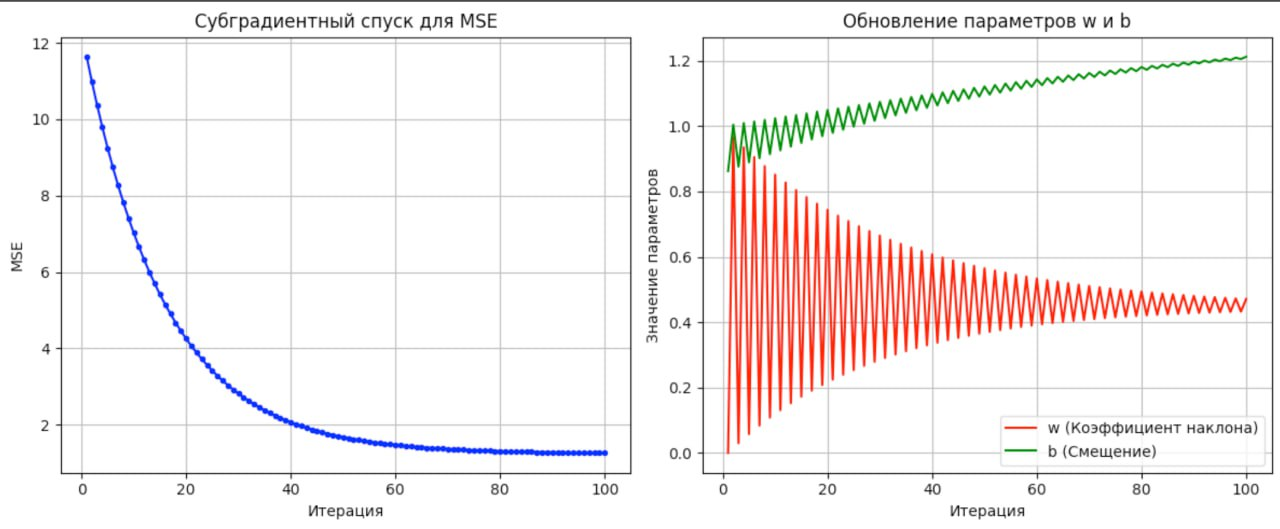

Ошибка скачет, потому что большой шаг обучения. Для субградиента по МАЕ l1 функция ошибки имеет острый угол в точке yi = ^yi, а ее субградиент — . А при больших шагах мы перепрыгиваем через оптимум. МАЕ нечувствительна к малым изменениям. На плато при маленьких ошибках получаем скачки. 


Муз-А-N-руза

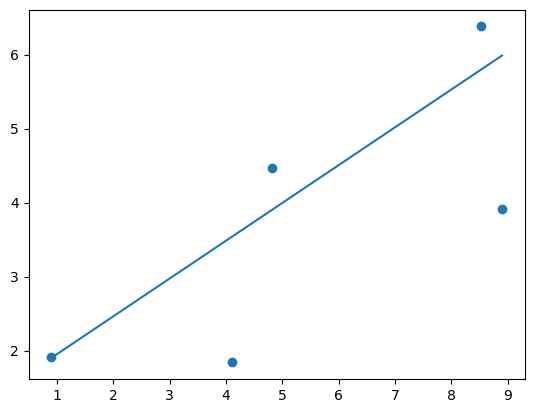

In [231]:
plt.scatter(df['x'],df['y'])
plt.plot(df['x'],df['y_pred'])
plt.show()

In [232]:
w,b

(0.5109999999999965, 1.4400000000000004)

In [233]:
df

,x,y,y_pred,err,w_change,b_change,err_abs
0,0.90,1.91,1.89990,-0.004940,0.90,1.0,0.01010
1,4.11,1.84,3.54021,-1.733226,4.11,1.0,1.70021
2,4.82,4.47,3.90302,0.529988,-4.82,-1.0,0.56698
3,8.53,6.38,5.79883,0.523402,-8.53,-1.0,0.58117
4,8.90,3.92,5.98790,-2.127740,8.90,1.0,2.06790


In [234]:
# Аналитическое решение. Псевдообратная матрица Муза Пенроуза
# Критерии использования с помощью псевдообратной матрицы должны выполняться для матрицы:
# 1. Матрица должна быть вырожденной, это может случиться, когда в матрице есть линейно зависимые признаки
# Вырожденная матрица — необратимая матрица. Матрица А называется вырожденной, если не существуетт матрицы А в -1 степени, такой что, А * А^-(1) = А^(-1) * Af""

In [235]:
df['x0'] = 1

In [236]:
df['x0']

0    1
1    1
2    1
3    1
4    1
Name: x0, dtype: int64

In [237]:
# X транспонированная
XT = df[["x", "x0"]].T

In [238]:
XTX =  XT @ df[["x", "x0"]]

In [ ]:
# обратная матрица
# мы возьмем не обратную, а псевдообратную матрицу Мура-Пенроуза
inv = np.linalg.pinv(XTX)


In [240]:
theta = (inv @ XT) @ df["y"]
theta

0    0.432780
1    1.344486
dtype: float64

In [241]:
# w = (X^T@X)+X^Ty

In [ ]:
from sklearn.linear_model import LinearRegression


In [245]:
model = LinearRegression()

In [247]:
model.fit(df[["x"]], df[["y"]])

LinearRegression()

In [257]:
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['x'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([[0.4327796]]),
 'rank_': 1,
 'singular_': array([6.65461344]),
 'intercept_': array([1.34448561])}

In [260]:
dir(model) # забыли

['__abstractmethods__',
 '__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__sklearn_clone__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_build_request_for_signature',
 '_check_feature_names',
 '_check_n_features',
 '_decision_function',
 '_doc_link_module',
 '_doc_link_template',
 '_doc_link_url_param_generator',
 '_estimator_type',
 '_get_default_requests',
 '_get_doc_link',
 '_get_metadata_request',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_parameter_constraints',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_set_intercept',
 '_validate_data',
 '_validate_params',
 'coef_',
 'copy_X',
 'feature_names_in_',
 'fit',

In [254]:
model.coef_

array([[0.4327796]])

In [256]:
model.intercept_

array([1.34448561])

In [259]:
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import SGDRegressor # это стохастический градиентный спуск, мы берем не полный батч, как в обычном градиентном спуске

In [ ]:
model_sgd = SGDRegressor()  # не успели